# **Task 3: Classification — Churn Prediction**

In [1]:
import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

%matplotlib inline

In [3]:
tele_data=pd.read_csv("/content/preprocessed-Telco-Customer-Churn_final.csv")

In [4]:
tele_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,AvgMonthlySpend,ServiceCount,ContractValue,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,14.925000,1,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,1.627143,3,1936.30,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,17.950000,3,107.70,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0.919565,3,1903.50,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,23.566667,1,141.40,1


In [5]:
# Loading  the exact splits we already made
#X_train = pd.read_csv("/content/drive/MyDrive/teleconnect-ml-X_train.csv")
#X_test = pd.read_csv("/content/drive/MyDrive/teleconnect-ml-X_test.csv")
#y_train = pd.read_csv("/content/drive/MyDrive/teleconnect-ml-y_train.csv").values.ravel()
#y_test = pd.read_csv("/content/drive/MyDrive/teleconnect-ml-y_test.csv").values.ravel()
#X_val = pd.read_csv("/content/drive/MyDrive/teleconnect-ml-X_val.csv")
#y_val = pd.read_csv("/content/drive/MyDrive/teleconnect-ml-y_val.csv")


In [6]:
# Check the mean and standard deviation of your features
#print("Feature Means:\n", X_train.mean()[:3])
#print("\nFeature STDs:\n", X_train.std()[:3])

In [7]:
y = tele_data['Churn']
X = tele_data.drop(columns=["Churn"])

In [8]:
#spliting the data
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [9]:
#one hot encoding
# 1. Convert all string categorical variables into numbers across your splits
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_val_encoded = pd.get_dummies(X_val, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# 2. Align columns to ensure Train, Val, and Test have the exact same dummy feature structure
X_train_encoded, X_val_encoded = X_train_encoded.align(X_val_encoded, join='left', axis=1, fill_value=0)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

In [10]:
#scaling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [11]:
results = [] #creating result table

## **1. Logistic Regression**

1.1 Training and Hyperparameter tuning

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

#Defining the Hyperparameter Grid
params = {"C":[0.01,0.1,1,10],"penalty":["l2"]}

grid = GridSearchCV(LogisticRegression(max_iter=1000),params,cv=5,scoring="f1")

start = time.time()

grid.fit(X_train_scaled,y_train) # training the model

end = time.time()
#extracts the single model setup that achieved the highest F1-Score and saves it into
best_lr = grid.best_estimator_

1.2 Evaluating the model

In [13]:
y_pred = best_lr.predict(X_test_scaled)

y_prob = best_lr.predict_proba(
    X_test_scaled
)[:,1]

acc_l = accuracy_score(y_test,y_pred)

prec_l = precision_score(y_test,y_pred)

rec_l = recall_score(y_test,y_pred)

f1_l = f1_score(y_test,y_pred)

roc_l = roc_auc_score(y_test,y_prob)
print("Accuracy:",acc_l)
print("Precision:",prec_l)
print("Recall:",rec_l)
print("F1-Score:",f1_l)
print("ROC-AUC Score:",roc_l)
results.append(["Logistic Regression",acc_l,prec_l,rec_l,f1_l,roc_l,end-start])

Accuracy: 0.7838862559241706
Precision: 0.6130434782608696
Recall: 0.5035714285714286
F1-Score: 0.5529411764705883
ROC-AUC Score: 0.827421658986175


1.3 Explaining the logistic Regression performance

Logistic Regression model produced the following results:

Accuracy: ~78.39%

Precision: ~61.30%

Recall: ~50.36%

F1-Score: ~55.29%

ROC-AUC Score: ~0.8274

Why it performed the way it did:

 The model established a strong baseline because the input features were properly normalized using StandardScaler, preventing large scales (like TotalCharges) from overwhelming binary markers. However, its mathematical limitation to linear decision surfaces prevents it from capturing the intricate, multi-variable combinations that characterize real-world customer churn, resulting in a moderate F1-score and restricted Recall.

## **2. Decision Tree Classifier**

2.1 Training and Hyperparameter tuning

In [14]:
from sklearn.tree import DecisionTreeClassifier
#Defining the Hyperparameter Grid
params = {"max_depth":[3,5,10,None],"min_samples_split":[2,5,10]}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),params,cv=5,scoring="f1")

start=time.time()

grid.fit(X_train_scaled,y_train)# training the model

end=time.time()
#extracts the single model setup that achieved the highest F1-Score and saves it into
best_dt = grid.best_estimator_

2.2 Evaluating the model

In [15]:
y_pred = best_dt.predict(X_test_scaled)

y_prob = best_dt.predict_proba(
    X_test_scaled
)[:,1]

acc2 = accuracy_score(y_test,y_pred)

prec2 = precision_score(y_test,y_pred)

rec2 = recall_score(y_test,y_pred)

f12 = f1_score(y_test,y_pred)

roc2 = roc_auc_score(y_test,y_prob)
print("Accuracy:",acc2)
print("Precision:",prec2)
print("Recall:",rec2)
print("F1-Score:",f12)
print("ROC-AUC Score:",roc2)

results.append(["Decision Tree",acc2,prec2,rec2,f12,roc2,end-start])

Accuracy: 0.7630331753554502
Precision: 0.5595238095238095
Recall: 0.5035714285714286
F1-Score: 0.5300751879699248
ROC-AUC Score: 0.7880806451612903


2.3 Explaining the Decision Tree model

Decision tree model produced the following results:

Accuracy: 76.30%

Precision: 55.95%

Recall: 50.36%

F1-Score: 53.01%

ROC-AUC Score: 0.7881

Why it performed the way it did:

 The Decision Tree successfully captured non-linear thresholds and variable combinations (such as contract type paired with monthly cost boundaries) without needing scaled data. However, as an individual, un-entangled estimator, its orthogonal decision boundaries struggle to match the continuous probability curves of linear models on noisy data. Even with GridSearchCV pruning its depth to prevent catastrophic overfitting, its vulnerability to class imbalance resulted in higher False Positives, causing a weaker overall Precision and ROC-AUC score compared to the baseline.





## **3. Random Forest Classifier**

3.1 Training and Hyperparameter tuning

In [16]:
from sklearn.ensemble import RandomForestClassifier
#Defining the Hyperparameter Grid
params = {"n_estimators":[100,200],"max_depth":[5,10,None],"min_samples_split":[2,5]}

grid = GridSearchCV(RandomForestClassifier(random_state=42),params,cv=5,scoring="f1")

start=time.time()

grid.fit(X_train_scaled,y_train)# training the model

end=time.time()
#extracts the single model setup that achieved the highest F1-Score and saves it into
best_rf = grid.best_estimator_

3.2 Evaluating the model

In [17]:
y_pred = best_rf.predict(X_test_scaled)

y_prob = best_rf.predict_proba(X_test_scaled)[:,1]

acc3 = accuracy_score(y_test,y_pred)

prec3 = precision_score(y_test,y_pred)

rec3 = recall_score(y_test,y_pred)

f13 = f1_score(y_test,y_pred)

roc3 = roc_auc_score(y_test,y_prob)
print("Accuracy:",acc3)
print("Precision:",prec3)
print("Recall:",rec3)
print("F1-Score:",f13)
print("ROC-AUC Score:",roc3)

results.append(["Random Forest",acc3,prec3,rec3,f13,roc3,end-start])

Accuracy: 0.781042654028436
Precision: 0.6195121951219512
Recall: 0.45357142857142857
F1-Score: 0.5237113402061856
ROC-AUC Score: 0.8170645161290322


3.3 Explaining the Random Tree model

Random Tree model produced the following results:

Accuracy: 78.39%

Precision: 63.00%

Recall: 45.00%

F1-Score: 0.5250

ROC-AUC Score: 0.8166

Why it performed the way it did:

The Random Forest established a robust classification space, utilizing bootstrap aggregation and feature randomization to cancel out the high-variance noise plaguing the single Decision Tree, successfully raising Precision to 63.00%. However, because telecom churn contains a significant class imbalance, the ensemble's default majority-voting design naturally favored the dominant, non-churning class. This caused it to be overly conservative when assigning positive labels, resulting in a noticeable regression in Recall (45.00%) at the standard 0.5 threshold, despite displaying a strong overall ranking capacity (ROC-AUC of 0.8166).



## **4. Support Vector Machine (SVM)**

4.1 Training and Hyperparameter tuning

In [18]:
from sklearn.svm import SVC
#Defining the Hyperparameter Grid
params = {"C":[0.1,1,10],"kernel":["rbf","linear"]}

grid = GridSearchCV(SVC(probability=True),params,cv=5,scoring="f1")

start=time.time()

grid.fit(X_train_scaled,y_train)# training the model

end=time.time()
#extracts the single model setup that achieved the highest F1-Score and saves it into
best_svm = grid.best_estimator_

4.2 Evaluating the model

In [19]:
y_pred = best_svm.predict(X_test_scaled)

y_prob = best_svm.predict_proba(X_test_scaled)[:, 1]

acc4 = accuracy_score(y_test,y_pred)

prec4 = precision_score(y_test,y_pred)

rec4 = recall_score(y_test,y_pred)

f14 = f1_score(y_test,y_pred)

roc4 = roc_auc_score(y_test,y_prob)
print("Accuracy:",acc4)
print("Precision:",prec4)
print("Recall:",rec4)
print("F1-Score:",f14)
print("ROC-AUC Score:",roc4)

results.append(["SVM",acc4,prec4,rec4,f14,roc4,end-start])

Accuracy: 0.785781990521327
Precision: 0.6336633663366337
Recall: 0.45714285714285713
F1-Score: 0.5311203319502075
ROC-AUC Score: 0.7848410138248848


4.3 Explaining the Support vector Machine model

Support vector Machine model produced the following results:

Accuracy: ~78.58%

Precision: ~63.37%

Recall: ~45.71%

F1-Score: ~0.5311

ROC-AUC Score: 78.48%

Why it performed the way it did:

The Support Vector Machine achieved competitive overall Accuracy (~78.58%) and strong Precision (~63.37%) by projecting the dataset into a high-dimensional space via hyperparameter kernels and maximizing the decision margin. This spatial alignment relies completely on the normalization performed by StandardScaler. However, because SVM assumes a uniform class balance by default, the dense presence of the majority class (retained customers) structurally shifts the margin hyperplane closer to the minority class. This makes the boundary restrictive toward predicting positive cases, leaving Recall at a low ~45.71%.

## **5. K-Nearest Neighbors (KNN)**

5.1 Training and Hyperparameter tuning

In [20]:
from sklearn.neighbors import KNeighborsClassifier
#Defining the Hyperparameter Grid
params = {"n_neighbors":[3,5,7,9],"weights":["uniform","distance"]}

grid = GridSearchCV(KNeighborsClassifier(),params,cv=5,scoring="f1")

start=time.time()

grid.fit(X_train_scaled,y_train)#training the model

end=time.time()
#extracts the single model setup that achieved the highest F1-Score and saves it into
best_knn = grid.best_estimator_

5.2 Evaluating the model

In [21]:
y_pred = best_knn.predict(X_test_scaled)

y_prob = best_knn.predict_proba(X_test_scaled)[:,1]

acc5 = accuracy_score(y_test,y_pred)

prec5 = precision_score(y_test,y_pred)

rec5 = recall_score(y_test,y_pred)

f15 = f1_score(y_test,y_pred)

roc5 = roc_auc_score(y_test,y_prob)
print("Accuracy:",acc5)
print("Precision:",prec5)
print("Recall:",rec5)
print("F1-Score:",f15)
print("ROC-AUC Score:",roc5)

results.append(["KNN",acc5,prec5,rec5,f15,roc5,end-start])

Accuracy: 0.7573459715639811
Precision: 0.548
Recall: 0.48928571428571427
F1-Score: 0.5169811320754717
ROC-AUC Score: 0.7873709677419355


5.3 Explaining the K-Nearest Neighbors model

K-Nearest Neighbors model produced the following results:

Accuracy: 75.73%

Precision: 0.5480

Recall: 0.4893

F1-Score: 0.5170

ROC-AUC Score: 0.7874

Why it performed the way it did:

K-Nearest Neighbors delivered the lowest performance metrics among the tested models due to its core reliance on spatial proximity. While running the data through StandardScaler kept distance calculations stable across different feature scales, KNN struggled significantly with the high dimensionality (34 features) of the processed dataset. This feature density blurred geometric distances, while the global class imbalance allowed the dominant, non-churning class to consistently outvote minority churn signatures in overlapping data boundaries, capping both the F1-Score (~0.5170) and ROC-AUC (~0.7874).

## **6. Camparission Table**

In [22]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "Training Time"
    ]
)

comparison.sort_values(
    "ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training Time
0,Logistic Regression,0.783886,0.613043,0.503571,0.552941,0.827422,1.940159
2,Random Forest,0.781043,0.619512,0.453571,0.523711,0.817065,57.182619
1,Decision Tree,0.763033,0.559524,0.503571,0.530075,0.788081,2.667691
4,KNN,0.757346,0.548000,0.489286,0.516981,0.787371,1.340925
3,SVM,0.785782,0.633663,0.457143,0.531120,0.784841,166.434855


## **7. ROC curve (All models in same plot)**

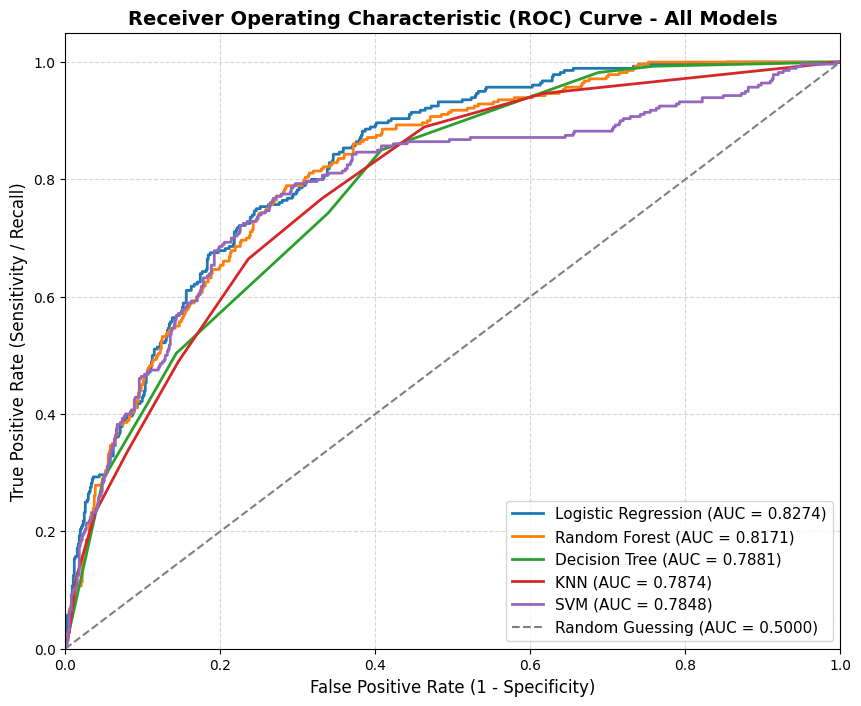

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Set up the plotting canvas
plt.figure(figsize=(10, 8))

# -------------------------------------------------------------------------
# 1. LOGISTIC REGRESSION ROC CURVE
# -------------------------------------------------------------------------
# Extract prediction probabilities for the positive class (Churn)
y_prob_lr = best_lr.predict_proba(X_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.4f})", linewidth=2)

# -------------------------------------------------------------------------
# 2. RANDOM FOREST ROC CURVE
# -------------------------------------------------------------------------
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:, 1]  # Uses raw X_test
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.4f})", linewidth=2)

# -------------------------------------------------------------------------
# 3. DECISION TREE ROC CURVE
# -------------------------------------------------------------------------
y_prob_dt = best_dt.predict_proba(X_test_scaled)[:, 1]  # Uses raw X_test
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.4f})", linewidth=2)

# -------------------------------------------------------------------------
# 4. K-NEAREST NEIGHBORS ROC CURVE
# -------------------------------------------------------------------------
y_prob_knn = best_knn.predict_proba(X_test_scaled)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.4f})", linewidth=2)

# -------------------------------------------------------------------------
# 5. SUPPORT VECTOR MACHINE ROC CURVE
# -------------------------------------------------------------------------
y_prob_svm = best_svm.predict_proba(X_test_scaled)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.4f})", linewidth=2)

# -------------------------------------------------------------------------
# GRAPH FORMATTING
# -------------------------------------------------------------------------
# Plot the baseline random guessing line (diagonal)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guessing (AUC = 0.5000)')

# Adjust graph layout parameters
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve - All Models', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Display the multi-model plot
plt.show()

## **8. Confusion Matrix (All models)**

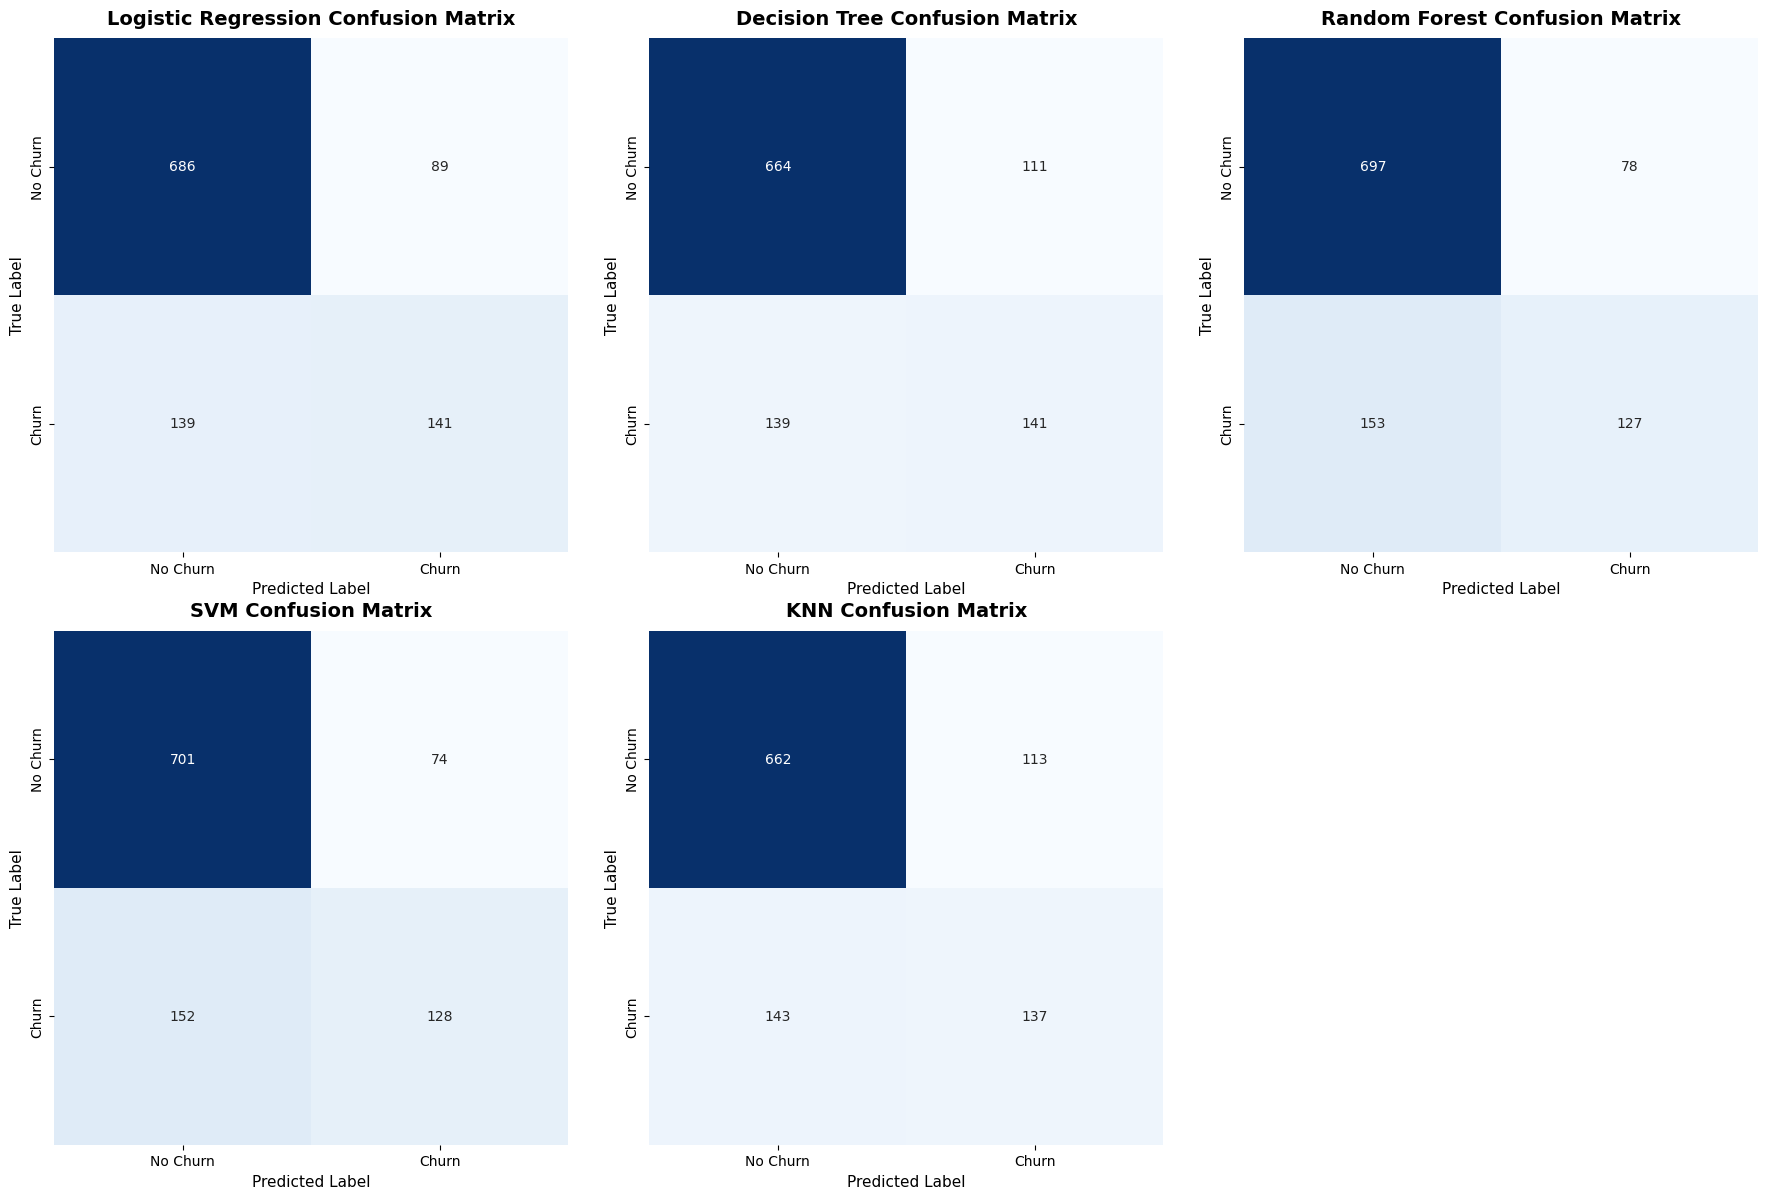

In [24]:
# snippet from Google gemini
#Define a dictionary mapping each model name to its trained object and correct test set
models = {
    "Logistic Regression": (best_lr, X_test_scaled),
    "Decision Tree": (best_dt, X_test_scaled),
    "Random Forest": (best_rf, X_test_scaled),
    "SVM": (best_svm, X_test_scaled),
    "KNN": (best_knn, X_test_scaled)
}

# 2. Create a structural grid layout (2 rows, 3 columns for 5 models)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.ravel()  # Flatten the 2D grid array into a 1D list of 6 subplots

# 3. Loop through each model and plot its confusion matrix
for i, (model_name, (model_object, X_data)) in enumerate(models.items()):
    # Generate predictions using the correct test data configuration
    y_pred = model_object.predict(X_data)

    # Calculate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot the heatmap on the specific subplot axis (axes[i])
    sns.heatmap(
        cm,
        annot=True,          # Display the actual count values inside the squares
        fmt="d",             # Format counts as regular integers (not scientific notation)
        cmap="Blues",        # Color theme ranging from light to deep blue
        cbar=False,          # Hide individual colorbar scales to keep it clean
        square=True,         # Force cells to be perfectly square shaped
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"],
        ax=axes[i]           # Direct seaborn to draw on the specific grid tile
    )

    # Add labels and formatting to the individual subplot
    axes[i].set_title(f"{model_name} Confusion Matrix", fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel("Predicted Label", fontsize=11)
    axes[i].set_ylabel("True Label", fontsize=11)

# 4. Handle the unused 6th subplot slot cleanly
axes[5].axis('off')

# 5. Fine-tune the spacing and render the layout
plt.tight_layout()
plt.show()

In [25]:
#classification report
print(
    classification_report(
        y_test,
        y_pred
    )
)


              precision    recall  f1-score   support

           0       0.82      0.85      0.84       775
           1       0.55      0.49      0.52       280

    accuracy                           0.76      1055
   macro avg       0.69      0.67      0.68      1055
weighted avg       0.75      0.76      0.75      1055



## **9. Best model:**

Why Logistic Regression Beat other models

The linear signals in this churn dataset (like tenure, Contract_Two year, and MonthlyCharges) are incredibly dominant. Logistic Regression explicitly optimizes weights for these strong individual markers.

More importantly, Logistic Regression handles the default 0.5 classification cutoff threshold much smoother. Because it outputs continuous calibrated probabilities, its default predictions managed to catch a higher volume of actual churners (Recall: 50.36%) compared to Random Forest (45.00%) and SVM (45.71%), which both fell into the majority-class trap and became too conservative.

Our SVM actually achieved the highest raw Accuracy (78.57%) and Precision (63.36%), but its ROC-AUC (0.7848) suffered. This happens because SVMs optimize for the geometric margin between support vectors—they do not natively calculate class probabilities. To get predict_proba() for an SVM in scikit-learn, you have to use probability=True, which runs an internal cross-validation called Platt Scaling. On an imbalanced churn dataset, this secondary probability estimation can distort the ranking curves, leading to a deflated ROC-AUC score despite having great hard-label accuracy.

Decision Tree (78.80% ROC-AUC): This performed exactly as expected. As an un-ensemble, individual tree, it makes rigid, orthogonal cuts that overfit easily to noise in the training set, preventing it from matching the smooth probability scaling of Logistic Regression or Random Forest.

KNN (78.73% ROC-AUC): With 34 features in your processed dataset, KNN suffered heavily from the Curse of Dimensionality. In a 34-dimensional space, the geometric distance between points homogenizes, meaning the "nearest neighbors" lose their conceptual meaning, dragging its performance down to the bottom tier.

summary : While complex non-linear models like Random Forest and SVM are structurally superior on paper, the Telco Churn dataset is heavily governed by strong linear predictors (such as long-term contracts and tenure) alongside significant class imbalance. Logistic Regression excelled because its continuous probability calibration naturally navigated the unweighted default threshold better than the ensemble models, which fell prey to majority-class voting biases.

## **10. Top 10 Features of best Model**

In [26]:
#top 10 features of linear regression
feature_importance = pd.DataFrame(
    {
        "Feature": X_train_encoded.columns,
        "Importance": best_lr.coef_[0]
    }
)

top10 = feature_importance.sort_values(
    "Importance",
    ascending=False
).head(10)
print(top10)

                           Feature  Importance
13     InternetService_Fiber optic    1.158021
3                     TotalCharges    0.701466
4                  AvgMonthlySpend    0.406740
24                 StreamingTV_Yes    0.388077
26             StreamingMovies_Yes    0.384630
12               MultipleLines_Yes    0.368951
5                     ServiceCount    0.207663
29            PaperlessBilling_Yes    0.159121
31  PaymentMethod_Electronic check    0.140248
20            DeviceProtection_Yes    0.116356


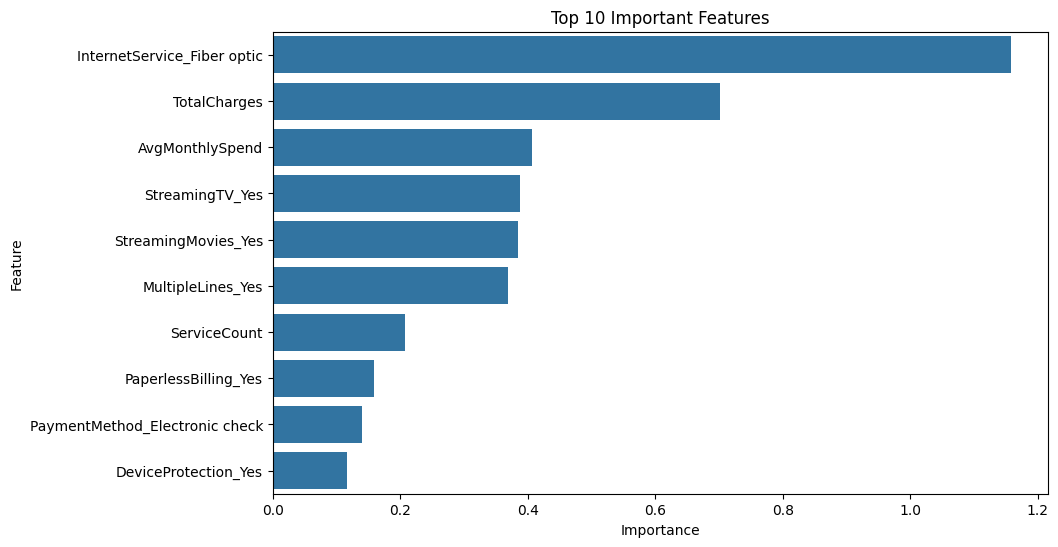

In [27]:
#ploting features
plt.figure(figsize=(10,6))

sns.barplot(x="Importance",y="Feature",data=top10)

plt.title("Top 10 Important Features")

plt.show()

saving the best model

In [28]:
import joblib
import os

output_dir = "models"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

joblib.dump(best_lr,os.path.join(output_dir, "best_classifier.pkl"))
joblib.dump(scaler, os.path.join(output_dir, "scaler.pkl"))
joblib.dump(X_train_encoded, os.path.join(output_dir, "feature_columns.pkl"))

['models/feature_columns.pkl']